In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=sns.load_dataset("tips")


In [4]:
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
df.shape


(244, 7)

In [7]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [8]:
df.sample(5)

,total_bill,tip,sex,smoker,day,time,size
217,11.59,1.5,Male,Yes,Sat,Dinner,2
141,34.30,6.7,Male,No,Thur,Lunch,6
243,18.78,3.0,Female,No,Thur,Dinner,2
2,21.01,3.5,Male,No,Sun,Dinner,3
109,14.31,4.0,Female,Yes,Sat,Dinner,2


In [9]:
df.groupby("day").count()

/var/folders/k7/7_x0yv8n1b7683v3m934hlp80000gn/T/ipykernel_81005/3420989895.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("day").count()


,total_bill,tip,sex,smoker,time,size
day,,,,,,
Thur,62,62,62,62,62,62
Fri,19,19,19,19,19,19
Sat,87,87,87,87,87,87
Sun,76,76,76,76,76,76


In [10]:
df1=df.groupby('day').sum(numeric_only=True)
df1.drop('size',inplace=True,axis=1)
df1['percent']=df1['tip']/df1['total_bill']*100
df1

/var/folders/k7/7_x0yv8n1b7683v3m934hlp80000gn/T/ipykernel_81005/2989027514.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1=df.groupby('day').sum(numeric_only=True)


,total_bill,tip,percent
day,,,
Thur,1096.33,171.83,15.673201
Fri,325.88,51.96,15.944519
Sat,1778.40,260.40,14.642375
Sun,1627.16,247.39,15.203791


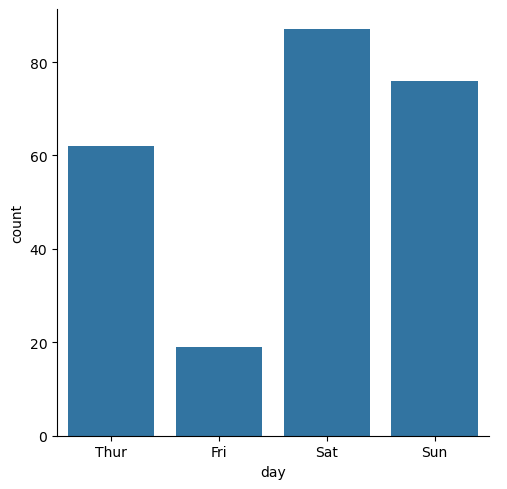

In [11]:
plt1=sns.catplot(x='day',kind='count',data=df);
plt.show()

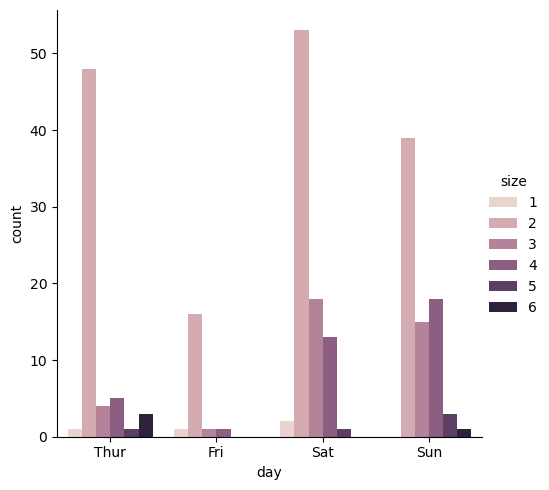

In [12]:
plt2=sns.catplot(x='day',hue="size",kind='count',data=df);
plt.show()

In [13]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [14]:
df.replace({'sex':{'Female':0,'Male':1},'smoker':{'Yes':1,'No':0}},inplace=True)
df.head()

/var/folders/k7/7_x0yv8n1b7683v3m934hlp80000gn/T/ipykernel_81005/1414269101.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'sex':{'Female':0,'Male':1},'smoker':{'Yes':1,'No':0}},inplace=True)
/var/folders/k7/7_x0yv8n1b7683v3m934hlp80000gn/T/ipykernel_81005/1414269101.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df.replace({'sex':{'Female':0,'Male':1},'smoker':{'Yes':1,'No':0}},inplace=True)
/var/folders/k7/7_x0yv8n1b7683v3m934hlp80000gn/T/ipykernel_81005/1414269101.py:1: FutureWarning: Downcasting behavior in `replace` is d

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,Sun,Dinner,2
1,10.34,1.66,1,0,Sun,Dinner,3
2,21.01,3.50,1,0,Sun,Dinner,3
3,23.68,3.31,1,0,Sun,Dinner,2
4,24.59,3.61,0,0,Sun,Dinner,4


In [15]:
days=pd.get_dummies(df['day'],dtype=int)
days.sample(5)

,Thur,Fri,Sat,Sun
201,1,0,0,0
197,1,0,0,0
7,0,0,0,1
36,0,0,1,0
95,0,1,0,0


In [16]:
times=pd.get_dummies(df['time'],dtype=int)
times.sample(5)

,Lunch,Dinner
66,0,1
153,0,1
11,0,1
33,0,1
133,1,0


In [17]:
df=pd.concat([df,days],axis=1)
df=pd.concat([df,times],axis=1)

In [18]:
df.sample(5)

,total_bill,tip,sex,smoker,day,time,size,Thur,Fri,Sat,Sun,Lunch,Dinner
201,12.74,2.01,0,1,Thur,Lunch,2,1,0,0,0,1,0
46,22.23,5.00,1,0,Sun,Dinner,2,0,0,0,1,0,1
47,32.40,6.00,1,0,Sun,Dinner,4,0,0,0,1,0,1
161,12.66,2.50,1,0,Sun,Dinner,2,0,0,0,1,0,1
4,24.59,3.61,0,0,Sun,Dinner,4,0,0,0,1,0,1


In [19]:
X=df[['sex','smoker','size','Thur','Fri','Sat','Sun','Dinner']]
Y=df[['tip']]

In [20]:
X.shape

(244, 8)

In [21]:
Y.shape

(244, 1)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [23]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)


In [24]:
regression=LinearRegression()
regression.fit(X_train,Y_train)


LinearRegression()

In [25]:
prediction=regression.predict(X_test)

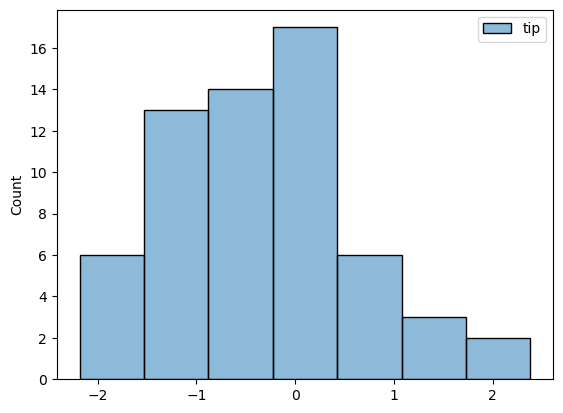

In [26]:
sns.histplot(Y_test-prediction)
plt.show()

In [29]:
X


,sex,smoker,size,Thur,Fri,Sat,Sun,Dinner
0,0,0,2,0,0,0,1,1
1,1,0,3,0,0,0,1,1
2,1,0,3,0,0,0,1,1
3,1,0,2,0,0,0,1,1
4,0,0,4,0,0,0,1,1
...,...,...,...,...,...,...,...,...
239,1,0,3,0,0,1,0,1
240,0,1,2,0,0,1,0,1
241,1,1,2,0,0,1,0,1
242,1,0,2,0,0,1,0,1


In [30]:
newCustomer=np.array([0,1,2,1,0,0,0,0]).reshape(1,-1)
regression.predict(newCustomer)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[2.47491008]])